# Log-MSE / log-R² comparison suite — self-contained rebuild

This notebook regenerates the log-MSE-aware comparison plots that were built across
`compare_all_experiments_v3.ipynb` and `feature_importance_analysis.ipynb`, restricted
to what can be reconstructed from exactly five CSVs:

- `results_shrinkage_full_metrics.csv` — all 19 pooled+shrinkage models, full metrics
- `results_gravity_edge_full_metrics.csv` — 12 gravity-edge variant configs
- `results_partial_pair_edgegat_full_metrics.csv` — 12 partial-pair/simplified variant configs
- `results_leave_one_out_full_metrics.csv` — 4 models × 18 features, retrained-without metrics
- `results_v2_chips_full_metrics.csv` — 19 dedicated chips-only models (the "old approach")

**What's included:** the log-R²-vs-log-MSE agreement checks (global grid, variants, LOO),
and a chips old-vs-new comparison.

**What's deliberately NOT included, and why:** the permutation-importance sections
(global ranked importance, GDELT block test, permutation-vs-LOO butterfly chart) needed
`feature_importance_shrinkage_summary.csv` / `feature_importance_shrinkage.csv`, neither
of which was provided here — so they're skipped rather than faked. The old-vs-new
comparison below is flagged explicitly: `results_v2_chips_full_metrics.csv` is evaluated
on the chips-only test set, while `results_shrinkage_full_metrics.csv` is evaluated on the
full all-products test set. The original old-vs-new comparison used a chips/8541+8542-slice
scope specifically (`results_shrinkage_head.csv`'s `HS_8541_8542_combined` scope), which
isn't available here — so this is a directional comparison, not a strictly matched one.

In [8]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'savefig.facecolor': '#ffffff',
    'axes.edgecolor': '#000000', 'axes.labelcolor': '#000000',
    'text.color': '#000000', 'xtick.color': '#000000', 'ytick.color': '#000000',
    'axes.grid': True, 'grid.color': '#000000', 'grid.alpha': 0.15, 'font.size': 10,
})
BLUE, ORANGE, POS, NEG, PURPLE, GRAY = '#4c8fbd', '#c47f3e', '#2ca02c', '#d62728', '#9467bd', '#888888'

# Looks in results/grids/ first (repo convention), falls back to the current directory
# (in case these 5 CSVs were dropped flat next to the notebook).
CANDIDATE_DIRS = ['../../results/grids', '.']

FILES = {
    'shrink':       'results_shrinkage_full_metrics.csv',
    'gravity':      'results_gravity_edge_full_metrics.csv',
    'partial_pair': 'results_partial_pair_edgegat_full_metrics.csv',
    'loo':          'results_leave_one_out_full_metrics.csv',
    'chips':        'results_v2_chips_full_metrics.csv',
}

def find_file(fname):
    for d in CANDIDATE_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    return None

paths = {}
for key, fname in FILES.items():
    p = find_file(fname)
    paths[key] = p
    print(f'  [{"found" if p else "MISSING"}]  {key:14s} -> {p or fname}')

  [found]  shrink         -> ../../results/grids/results_shrinkage_full_metrics.csv
  [found]  gravity        -> ../../results/grids/results_gravity_edge_full_metrics.csv
  [found]  partial_pair   -> ../../results/grids/results_partial_pair_edgegat_full_metrics.csv
  [found]  loo            -> ../../results/grids/results_leave_one_out_full_metrics.csv
  [found]  chips          -> ../../results/grids/results_v2_chips_full_metrics.csv


### Mosaic helper

Every metric gets its own independent figure (never combined subplots), so any single
plot can be saved on its own.

In [9]:
def plot_metric_mosaic(index, series, metrics, metric_labels=None, title_prefix='',
                       orientation='horizontal', panel_size=(6, 6), value_fmt=None, rotation=30):
    """index: list of category/feature labels
    series: {series_label: {metric_name: array-like aligned with index}}
    metrics: candidate metric names -- only ones present in EVERY series are actually plotted
    Each metric gets its OWN independent figure.
    """
    metric_labels = metric_labels or {}
    available = [m for m in metrics if all(m in s for s in series.values())]
    if not available:
        print(f'[skip mosaic] none of {metrics} available in all series for "{title_prefix}"')
        return []
    palette = [BLUE, ORANGE, PURPLE, GRAY]
    n_series = len(series)
    x = np.arange(len(index)); w = 0.8 / n_series
    figs = []
    for metric in available:
        fig, ax = plt.subplots(figsize=panel_size)
        for si, (label, data) in enumerate(series.items()):
            vals = np.asarray(data[metric], dtype=float)
            off = -w*n_series/2 + w*(si + 0.5)
            if orientation == 'vertical':
                ax.bar(x + off, vals, w, label=label, color=palette[si % len(palette)])
            else:
                ax.barh(x + off, vals, w, label=label, color=palette[si % len(palette)])
            if value_fmt:
                for xi, v in zip(x + off, vals):
                    if orientation == 'vertical':
                        ax.text(xi, v, value_fmt.format(v), ha='center', va='bottom', fontsize=6)
                    else:
                        ax.text(v, xi, value_fmt.format(v), ha='left', va='center', fontsize=6)
        if orientation == 'vertical':
            ax.set_xticks(x); ax.set_xticklabels(index, rotation=rotation, ha='right', fontsize=8)
            ax.axhline(0, color='black', lw=.5)
        else:
            ax.set_yticks(x); ax.set_yticklabels(index, fontsize=8); ax.invert_yaxis()
            ax.axvline(0, color='black', lw=.5)
        ax.set_title(f'{title_prefix}\n{metric_labels.get(metric, metric)}', fontsize=10, fontweight='bold')
        if n_series > 1:
            ax.legend(fontsize=7, loc='best')
        fig.tight_layout()
        figs.append((fig, ax))
    return figs

METRIC_LABELS = {'log_r2': 'log-R\u00b2 (higher = better)', 'spearman': 'Spearman \u03c1 (higher = better)',
                 'smape': 'SMAPE % (lower = better)', 'log_mse': 'log-MSE (lower = better)'}

def parse_model_name(name):
    """Handles both '..._shrinkage' (pooled+shrinkage grid) and bare (chips/old-approach grid) names."""
    n = name.replace('_shrinkage', '')
    if n == 'GAT_first_none':
        return ('GAT', 'none', 'none')
    if n.startswith('GAT_first_'):
        rest = n[len('GAT_first_'):]
        scoring, fusion = rest.rsplit('_', 1)
        return ('GAT', fusion, scoring)
    if n.startswith('EdgeGAT_full_'):
        rest = n[len('EdgeGAT_full_'):]
        fusion, combo = rest.split('_', 1)
        return ('EdgeGAT_full', fusion, combo)
    raise ValueError(name)

## 1. Global 19-model grid — log-R² vs log-MSE agreement

Everywhere else in the project, model quality is reported via log-R². `log_mse` is
computed directly in log1p-space (never routed through `expm1`, so it can't blow up
from exponentiation overflow the way raw-scale MSE can). This checks whether the two
metrics ever disagree on which model is best.

Spearman correlation between the two rankings: 1.000
Largest rank disagreement: GAT_first_topk_blend_shrinkage (|Δrank|=0)


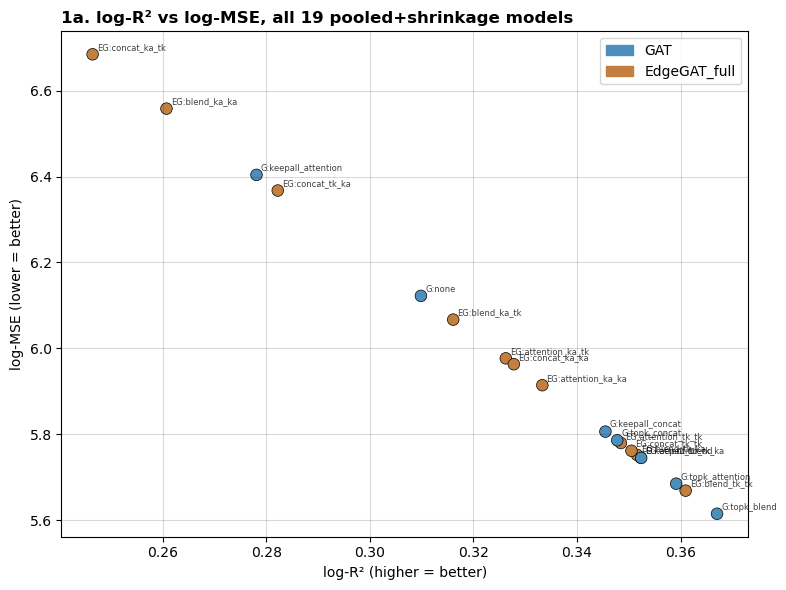

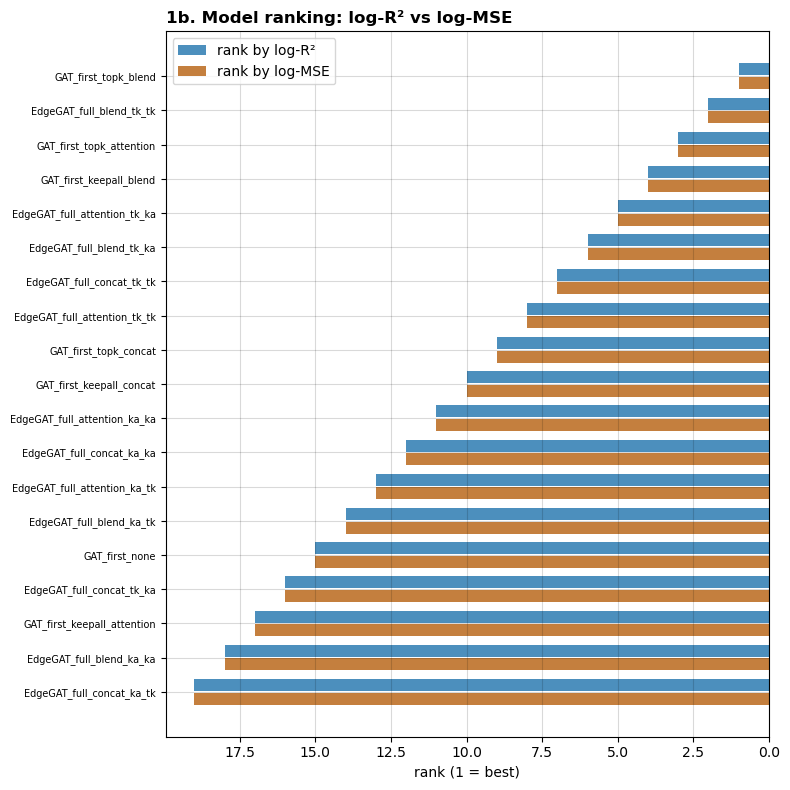

In [10]:
if paths['shrink']:
    full = pd.read_csv(paths['shrink']).set_index('model')
    full['is_edgegat'] = full.index.str.startswith('EdgeGAT_full')

    fig, ax = plt.subplots(figsize=(8, 6))
    colors_fm = [ORANGE if e else BLUE for e in full['is_edgegat']]
    ax.scatter(full['log_r2'], full['log_mse'], c=colors_fm, s=70, edgecolor='black', linewidth=0.5)
    for name, row in full.iterrows():
        label = name.replace('_shrinkage', '').replace('EdgeGAT_full_', 'EG:').replace('GAT_first_', 'G:')
        ax.annotate(label, (row['log_r2'], row['log_mse']), fontsize=6, alpha=0.75,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('log-R\u00b2 (higher = better)'); ax.set_ylabel('log-MSE (lower = better)')
    ax.set_title('1a. log-R\u00b2 vs log-MSE, all 19 pooled+shrinkage models', loc='left', fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=BLUE, label='GAT'), Patch(color=ORANGE, label='EdgeGAT_full')])
    fig.tight_layout()

    rank_r2 = full['log_r2'].rank(ascending=False)
    rank_mse = full['log_mse'].rank(ascending=True)
    rank_df = pd.DataFrame({'rank_by_log_r2': rank_r2, 'rank_by_log_mse': rank_mse}).sort_values('rank_by_log_r2')
    y = np.arange(len(rank_df))
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.barh(y - 0.2, rank_df['rank_by_log_r2'], 0.35, label='rank by log-R\u00b2', color=BLUE)
    ax.barh(y + 0.2, rank_df['rank_by_log_mse'], 0.35, label='rank by log-MSE', color=ORANGE)
    ax.set_yticks(y); ax.set_yticklabels([n.replace('_shrinkage', '') for n in rank_df.index], fontsize=7)
    ax.invert_yaxis(); ax.invert_xaxis()
    ax.set_xlabel('rank (1 = best)'); ax.legend()
    ax.set_title('1b. Model ranking: log-R\u00b2 vs log-MSE', loc='left', fontweight='bold')
    fig.tight_layout()

    rank_disagreement = (rank_df['rank_by_log_r2'] - rank_df['rank_by_log_mse']).abs()
    corr = rank_df['rank_by_log_r2'].corr(rank_df['rank_by_log_mse'], method='spearman')
    print(f"Spearman correlation between the two rankings: {corr:.3f}")
    print(f"Largest rank disagreement: {rank_disagreement.idxmax()} (|\u0394rank|={rank_disagreement.max():.0f})")
else:
    print('[skip] results_shrinkage_full_metrics.csv not found.')

## 2. Retraining variants — gravity-edge & partial-pair, log-R² vs log-MSE

Same check as Section 1, applied to the two variant families where the recompute
succeeded (pruned's threshold sweep can't be recomputed — its per-model kept-column
list depended on `feature_importance_shrinkage.csv` at values that have since drifted).

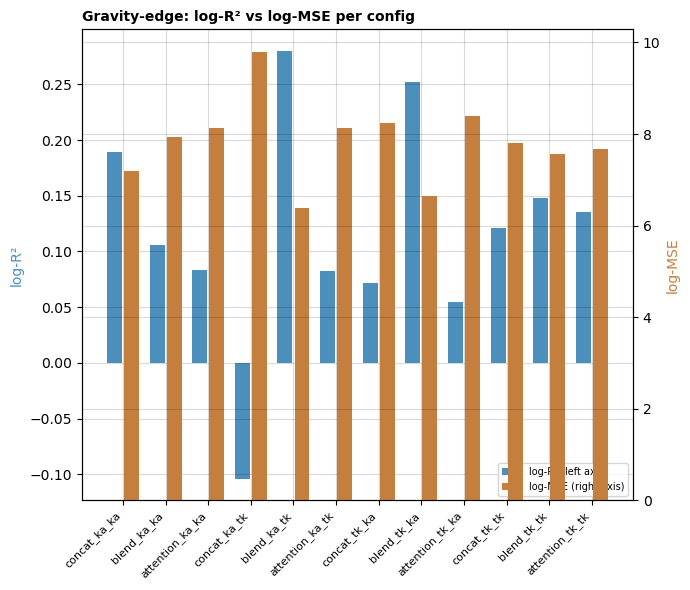

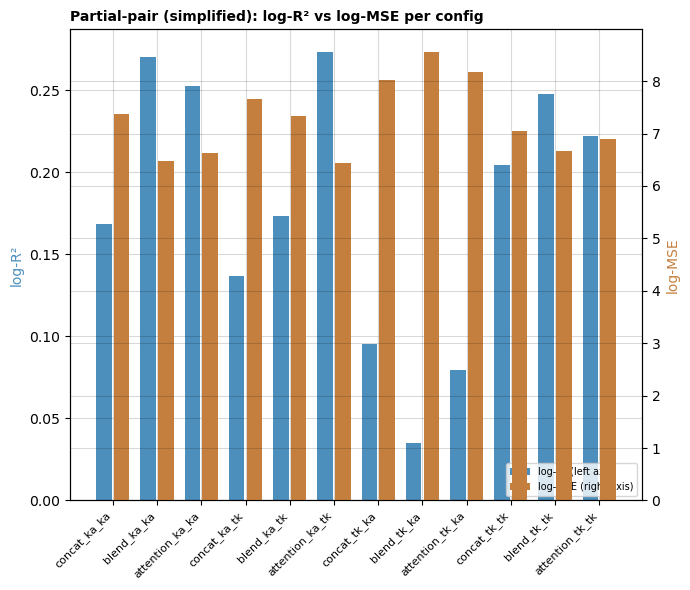

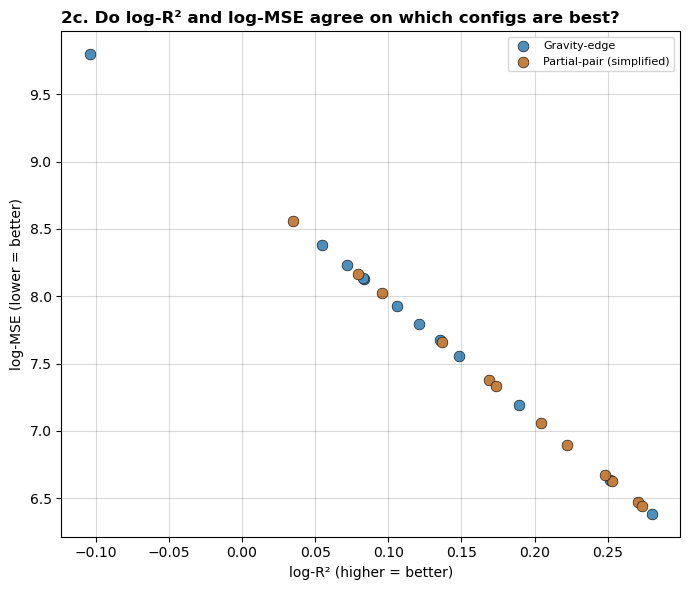

In [11]:
variant_files = {'Gravity-edge': paths['gravity'], 'Partial-pair (simplified)': paths['partial_pair']}
loaded_variants = {}
for label, p in variant_files.items():
    if p:
        loaded_variants[label] = pd.read_csv(p).set_index('name')
    else:
        print(f'[skip] {label} not found')

if loaded_variants:
    for label, df in loaded_variants.items():
        fig, ax = plt.subplots(figsize=(7, 6))
        x = np.arange(len(df))
        ax2 = ax.twinx()
        ax.bar(x - 0.2, df['log_r2'], 0.35, color=BLUE, label='log-R\u00b2 (left axis)')
        ax2.bar(x + 0.2, df['log_mse'], 0.35, color=ORANGE, label='log-MSE (right axis)')
        ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('log-R\u00b2', color=BLUE); ax2.set_ylabel('log-MSE', color=ORANGE)
        ax.set_title(f'{label}: log-R\u00b2 vs log-MSE per config', loc='left', fontweight='bold', fontsize=10)
        h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1+h2, l1+l2, fontsize=7, loc='lower right')
        fig.tight_layout()

    fig, ax = plt.subplots(figsize=(7, 6))
    variant_colors = {'Gravity-edge': BLUE, 'Partial-pair (simplified)': ORANGE}
    for label, df in loaded_variants.items():
        ax.scatter(df['log_r2'], df['log_mse'], color=variant_colors[label], s=60,
                   edgecolor='black', linewidth=0.4, label=label)
    ax.set_xlabel('log-R\u00b2 (higher = better)'); ax.set_ylabel('log-MSE (lower = better)')
    ax.set_title('2c. Do log-R\u00b2 and log-MSE agree on which configs are best?', loc='left', fontweight='bold')
    ax.legend(fontsize=8)
    fig.tight_layout()
else:
    print('No variant files available.')

## 3. Leave-one-out — does log-MSE agree with log-R² (and spearman) on which features matter?

`results_leave_one_out_full_metrics.csv` already carries `log_r2`, `log_mse`, and
`spearman` per (model, feature_removed) — no need for a separate log_r2-only file this
time. Deltas are computed against each model's own baseline row in
`results_shrinkage_full_metrics.csv`.

log-R² and log-MSE agree on direction for 18/18 features.


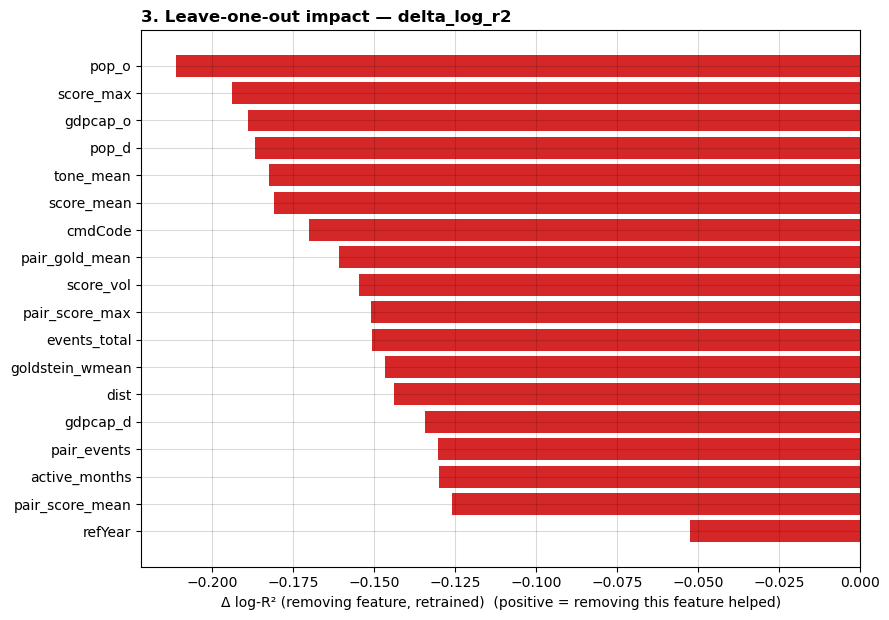

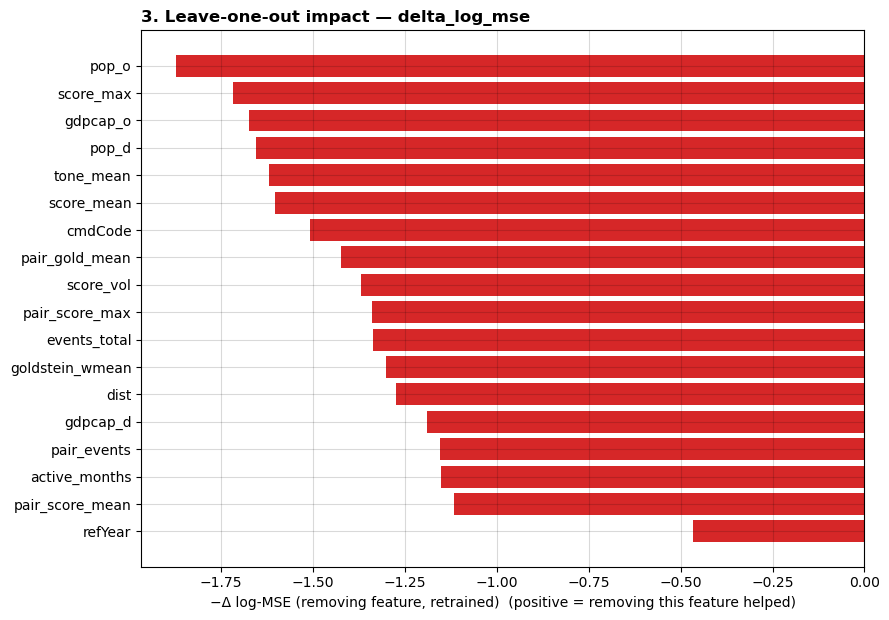

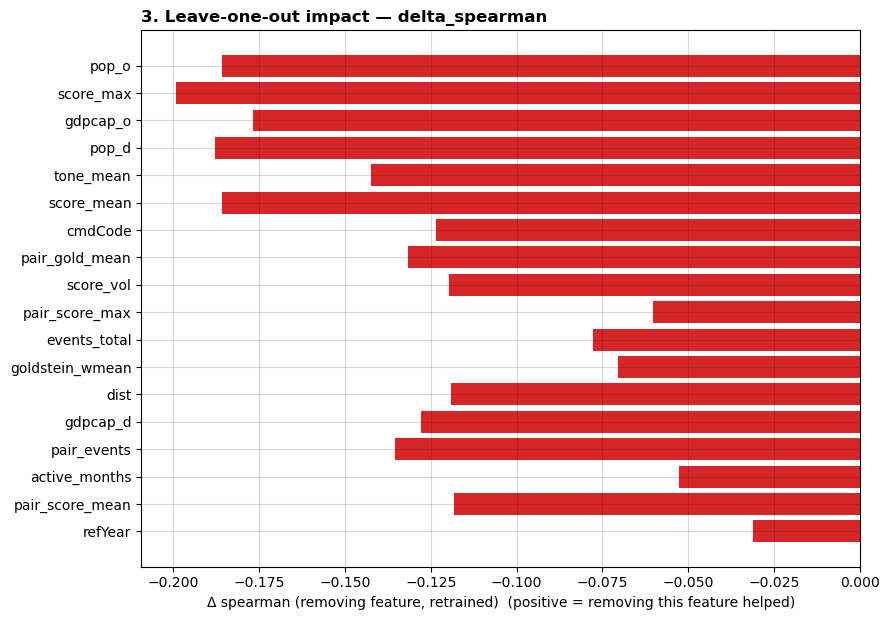

In [12]:
if paths['loo'] and paths['shrink']:
    loo_fm = pd.read_csv(paths['loo'])
    full_metrics = pd.read_csv(paths['shrink']).set_index('model')
    baseline = {idx.replace('_shrinkage', ''): row for idx, row in full_metrics.iterrows()}

    for metric, better in [('log_r2', 'higher'), ('log_mse', 'lower'), ('spearman', 'higher')]:
        loo_fm[f'baseline_{metric}'] = loo_fm['model'].map(lambda m: baseline[m][metric] if m in baseline else np.nan)
        loo_fm[f'delta_{metric}'] = loo_fm[metric] - loo_fm[f'baseline_{metric}']

    pivot = loo_fm.pivot_table(index='feature_removed',
                                values=['delta_log_r2', 'delta_log_mse', 'delta_spearman'], aggfunc='mean')
    pivot = pivot.sort_values('delta_log_r2')

    for metric, ylabel, flip in [('delta_log_r2', '\u0394 log-R\u00b2 (removing feature, retrained)', False),
                                  ('delta_log_mse', '\u2212\u0394 log-MSE (removing feature, retrained)', True),
                                  ('delta_spearman', '\u0394 spearman (removing feature, retrained)', False)]:
        vals = -pivot[metric] if flip else pivot[metric]
        colors = [POS if v >= 0 else NEG for v in vals]
        fig, ax = plt.subplots(figsize=(9, max(5, 0.35*len(pivot))))
        ax.barh(pivot.index, vals, color=colors)
        ax.axvline(0, color='black', lw=.6)
        ax.set_xlabel(f'{ylabel}  (positive = removing this feature helped)')
        ax.set_title(f'3. Leave-one-out impact \u2014 {metric}', loc='left', fontweight='bold')
        ax.invert_yaxis()
        fig.tight_layout()

    agree = np.sign(pivot['delta_log_r2']) == np.sign(-pivot['delta_log_mse'])
    print(f'log-R\u00b2 and log-MSE agree on direction for {agree.sum()}/{len(pivot)} features.')
    if (~agree).any():
        print('Features where they disagree:')
        for feat in pivot.index[~agree]:
            print(f"  {feat}: \u0394log_r2={pivot.loc[feat,'delta_log_r2']:+.4f}, "
                  f"\u0394log_mse={pivot.loc[feat,'delta_log_mse']:+.4f}")
else:
    print('[skip] results_leave_one_out_full_metrics.csv or results_shrinkage_full_metrics.csv not found.')

## 4. Old approach (dedicated chips-only models) — standalone

The 19 dedicated chips-only configs from `train_benchmark.py`, on their own metrics
(this is the population `log_r2`/`log_mse` were computed on — the chips-only 2023 test
set, not the pooled all-products one).

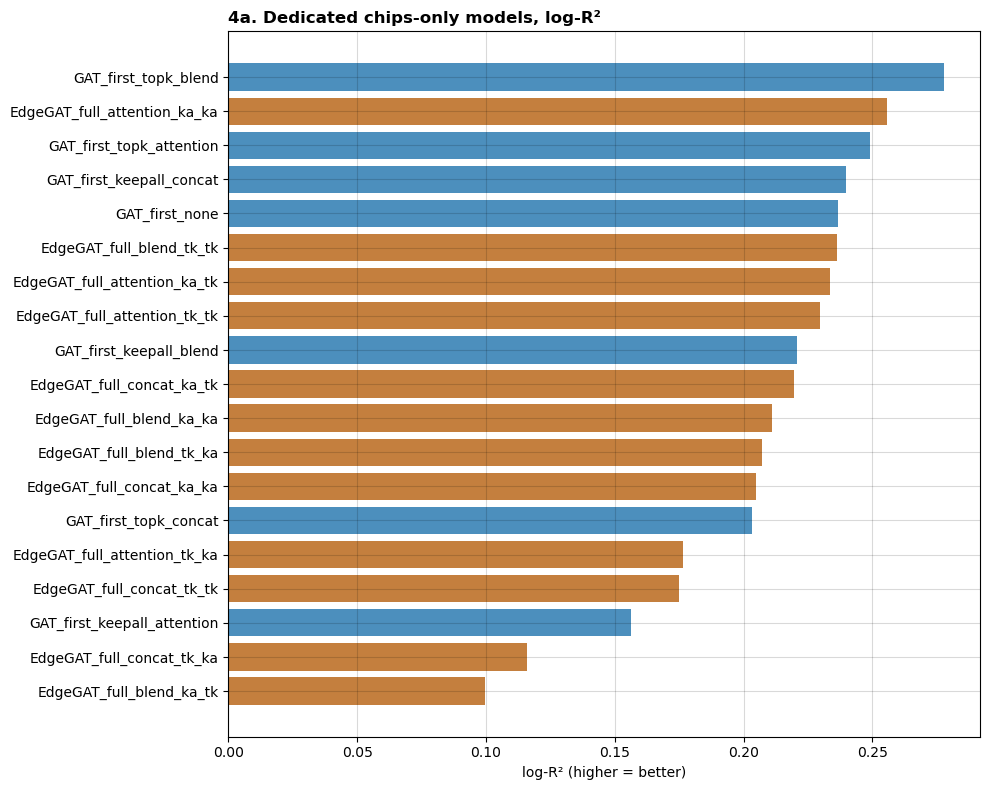

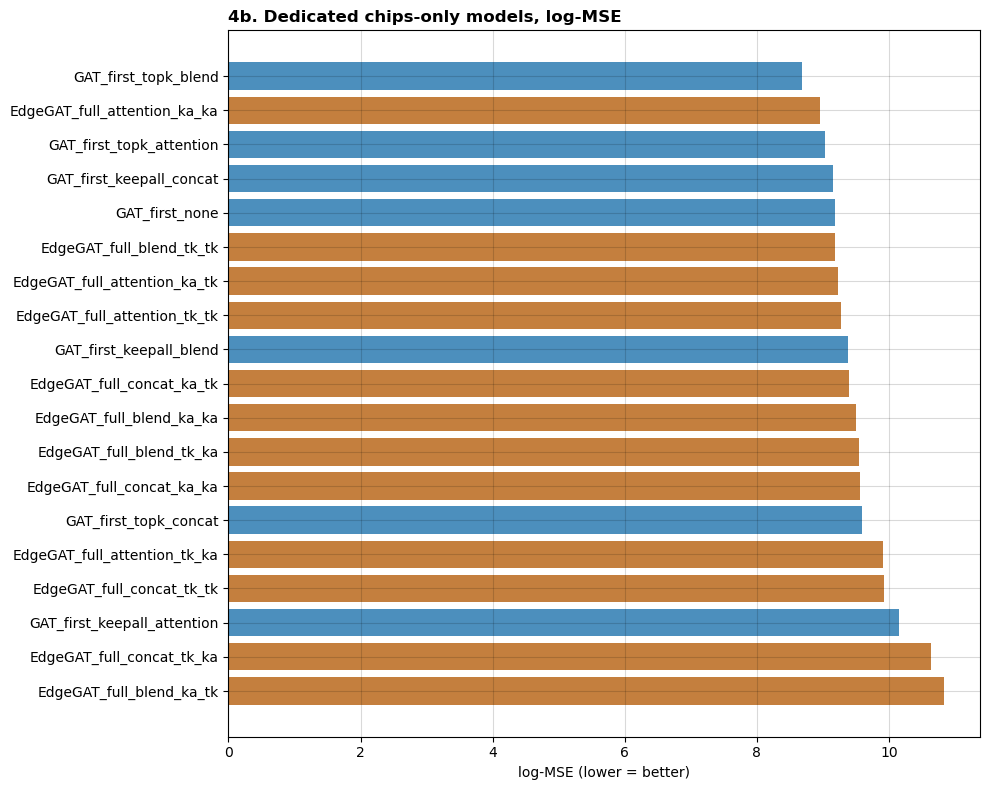

In [13]:
if paths['chips']:
    chips_fm = pd.read_csv(paths['chips']).set_index('model')
    fig, ax = plt.subplots(figsize=(10, 8))
    order = chips_fm['log_r2'].sort_values(ascending=False).index
    colors = [ORANGE if n.startswith('EdgeGAT_full') else BLUE for n in order]
    ax.barh(order, chips_fm.loc[order, 'log_r2'], color=colors)
    ax.set_xlabel('log-R\u00b2 (higher = better)')
    ax.set_title('4a. Dedicated chips-only models, log-R\u00b2', loc='left', fontweight='bold')
    ax.invert_yaxis()
    fig.tight_layout()

    fig, ax = plt.subplots(figsize=(10, 8))
    order = chips_fm['log_mse'].sort_values(ascending=True).index
    colors = [ORANGE if n.startswith('EdgeGAT_full') else BLUE for n in order]
    ax.barh(order, chips_fm.loc[order, 'log_mse'], color=colors)
    ax.set_xlabel('log-MSE (lower = better)')
    ax.set_title('4b. Dedicated chips-only models, log-MSE', loc='left', fontweight='bold')
    ax.invert_yaxis()
    fig.tight_layout()

    chips_fm[['log_r2', 'log_mse', 'spearman', 'smape']].sort_values('log_r2', ascending=False)
else:
    print('[skip] results_v2_chips_full_metrics.csv not found.')

## 5. Old vs. new — chips-only vs pooled+shrinkage (⚠️ scope caveat, read this first)

**This comparison is directional, not strictly matched.** `results_v2_chips_full_metrics.csv`
is evaluated on the chips-only 2023 test set. `results_shrinkage_full_metrics.csv` is
evaluated on the full all-products 2023 test set. The paper's original old-vs-new table
used a chips/HS-8541+8542-slice scope specifically (via `results_shrinkage_head.csv`'s
`HS_8541_8542_combined` scope), which isn't part of this upload. Treat the numbers below
as "does the pooled+shrinkage architecture look competitive at all", not as the paper's
headline figure — regenerate Section 6b of `compare_all_experiments_v3.ipynb` with the
correctly-scoped file for the actual paper table.

Pooled+shrinkage beats the (differently-scoped) chips-only model on log-R² in 19/19 configs.
Reminder: different eval populations -- see the scope caveat above.


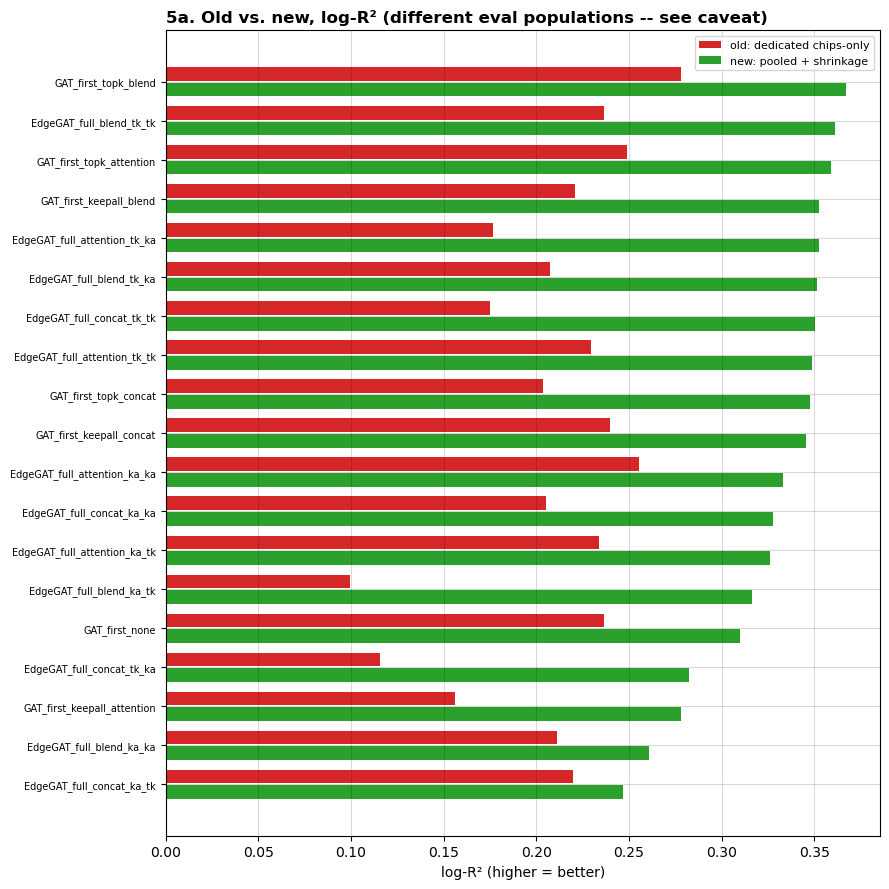

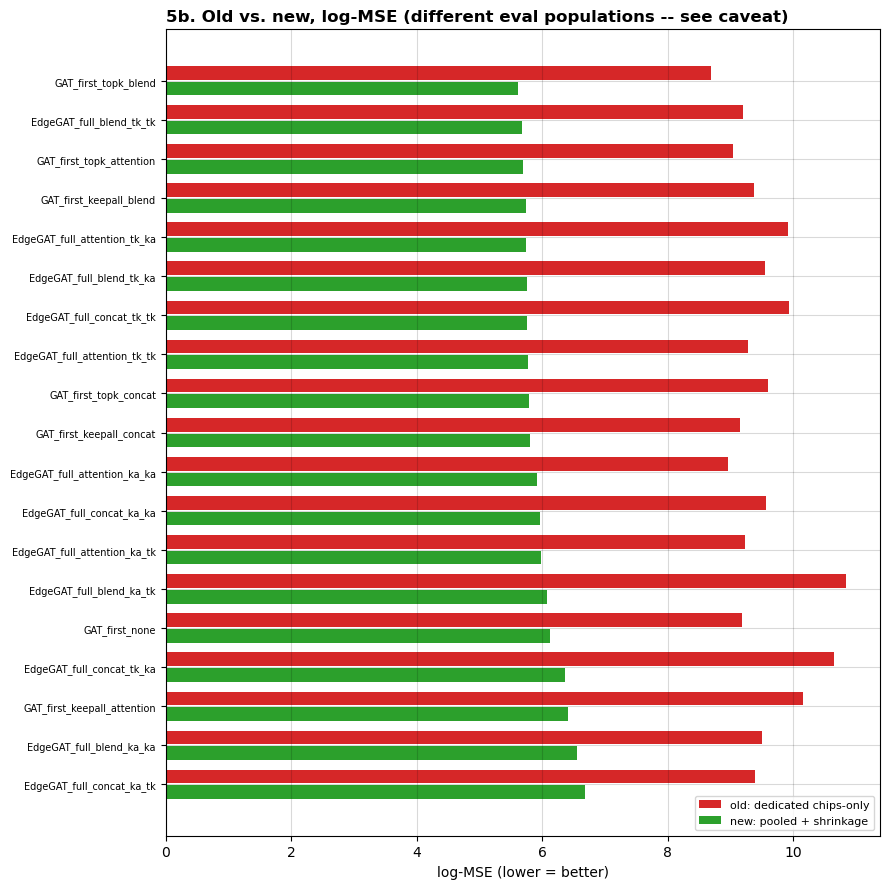

In [14]:
if paths['chips'] and paths['shrink']:
    chips_fm = pd.read_csv(paths['chips']).set_index('model')
    full = pd.read_csv(paths['shrink']).set_index('model')

    rows = []
    for name, row in full.iterrows():
        chips_name = name.replace('_shrinkage', '')
        if chips_name not in chips_fm.index:
            continue
        rows.append({'label': chips_name,
                     'old_log_r2': chips_fm.loc[chips_name, 'log_r2'], 'new_log_r2': row['log_r2'],
                     'old_log_mse': chips_fm.loc[chips_name, 'log_mse'], 'new_log_mse': row['log_mse']})
    comp = pd.DataFrame(rows).set_index('label').sort_values('new_log_r2', ascending=False)
    n_beat = (comp['new_log_r2'] > comp['old_log_r2']).sum()
    print(f'Pooled+shrinkage beats the (differently-scoped) chips-only model on log-R\u00b2 in {n_beat}/{len(comp)} configs.')
    print('Reminder: different eval populations -- see the scope caveat above.')

    fig, ax = plt.subplots(figsize=(9, 9))
    y = np.arange(len(comp))
    ax.barh(y - 0.2, comp['old_log_r2'], 0.35, color=NEG, label='old: dedicated chips-only')
    ax.barh(y + 0.2, comp['new_log_r2'], 0.35, color=POS, label='new: pooled + shrinkage')
    ax.set_yticks(y); ax.set_yticklabels(comp.index, fontsize=7); ax.invert_yaxis()
    ax.set_xlabel('log-R\u00b2 (higher = better)')
    ax.set_title('5a. Old vs. new, log-R\u00b2 (different eval populations -- see caveat)', loc='left', fontweight='bold')
    ax.legend(fontsize=8)
    fig.tight_layout()

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.barh(y - 0.2, comp['old_log_mse'], 0.35, color=NEG, label='old: dedicated chips-only')
    ax.barh(y + 0.2, comp['new_log_mse'], 0.35, color=POS, label='new: pooled + shrinkage')
    ax.set_yticks(y); ax.set_yticklabels(comp.index, fontsize=7); ax.invert_yaxis()
    ax.set_xlabel('log-MSE (lower = better)')
    ax.set_title('5b. Old vs. new, log-MSE (different eval populations -- see caveat)', loc='left', fontweight='bold')
    ax.legend(fontsize=8)
    fig.tight_layout()

    comp
else:
    print('[skip] results_v2_chips_full_metrics.csv or results_shrinkage_full_metrics.csv not found.')